In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [22]:
latent_dim = 64          # Smaller latent vector
batch_size = 128         # Larger batch for faster learning
lr = 0.0002
epochs = 50

In [23]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


In [24]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 784),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        return img

# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        validity = self.model(img)
        return validity

# Initialize models
generator = Generator().to(device)
discriminator = Discriminator().to(device)

In [25]:
optimizer_G = optim.Adam(generator.parameters(), lr=lr)
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr)
adversarial_loss = nn.BCELoss()

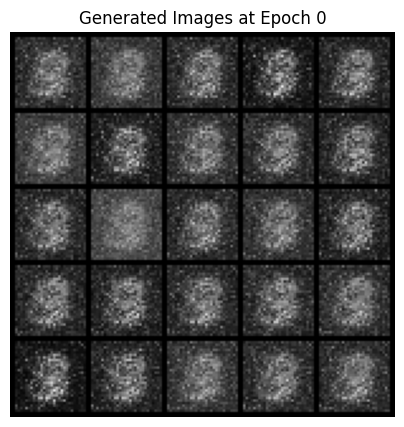

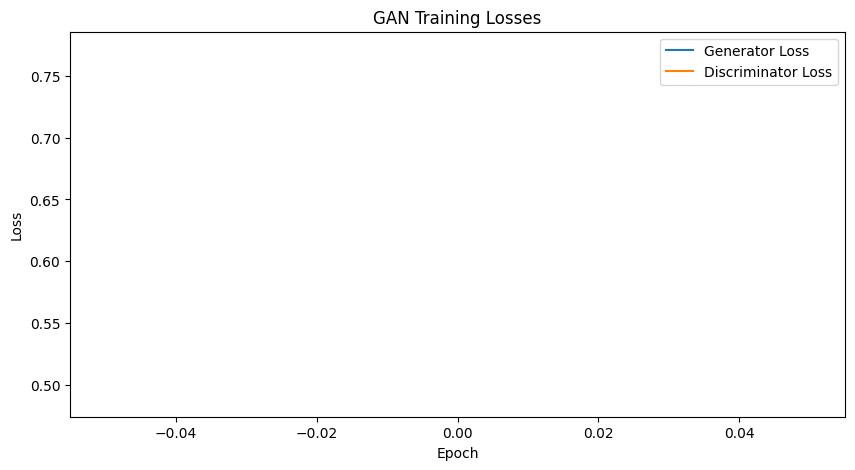

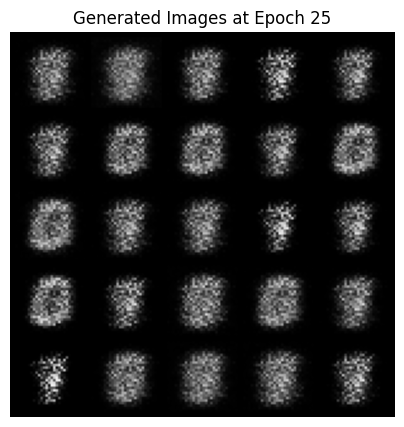

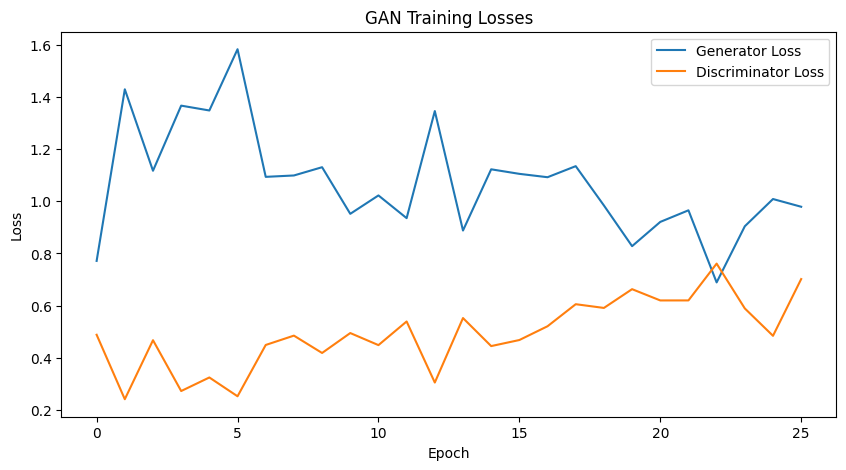

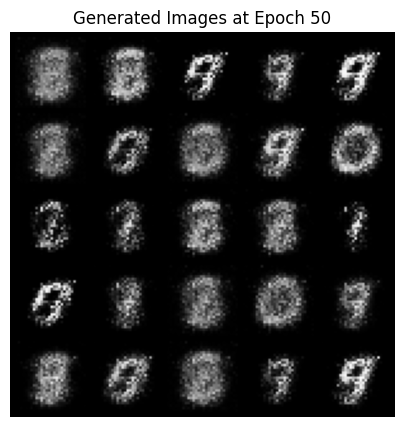

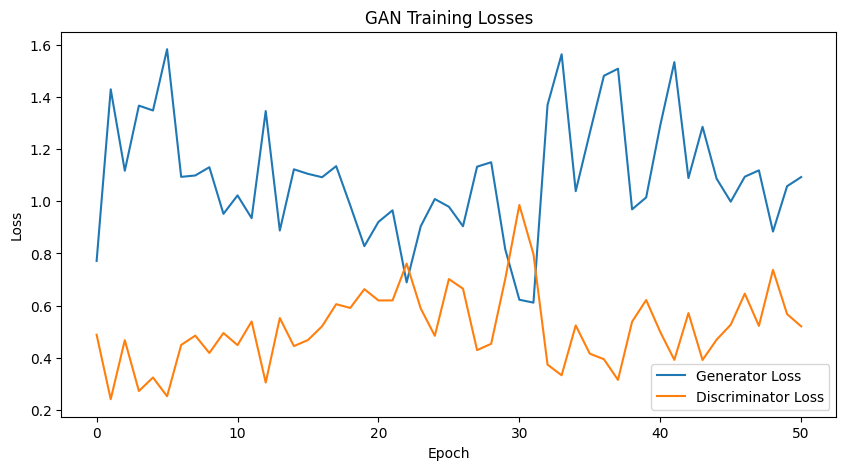

In [26]:
losses_G = []
losses_D = []

fixed_noise = torch.randn(25, latent_dim).to(device)

for epoch in range(epochs + 1):
    for imgs, _ in loader:
        imgs = imgs.view(imgs.size(0), -1).to(device)

        real = torch.ones(imgs.size(0), 1).to(device)
        fake = torch.zeros(imgs.size(0), 1).to(device)

        # Train Generator
        optimizer_G.zero_grad()
        z = torch.randn(imgs.size(0), latent_dim).to(device)
        generated_imgs = generator(z)
        g_loss = adversarial_loss(discriminator(generated_imgs), real)
        g_loss.backward()
        optimizer_G.step()

        # Train Discriminator
        optimizer_D.zero_grad()
        real_loss = adversarial_loss(discriminator(imgs), real)
        fake_loss = adversarial_loss(discriminator(generated_imgs.detach()), fake)
        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()

    # Save losses
    losses_G.append(g_loss.item())
    losses_D.append(d_loss.item())

    # Show samples at Epoch 0, 25, and 50
    if epoch in [0, 25, 50]:
        with torch.no_grad():
            samples = generator(fixed_noise).view(-1, 1, 28, 28)
            samples = samples * 0.5 + 0.5  # denormalize
            grid = torchvision.utils.make_grid(samples, nrow=5)
            plt.figure(figsize=(5,5))
            plt.imshow(np.transpose(grid.cpu(), (1,2,0)))
            plt.title(f"Generated Images at Epoch {epoch}")
            plt.axis('off')
            plt.show()
            plt.figure(figsize=(10,5))
            plt.plot(losses_G, label="Generator Loss")
            plt.plot(losses_D, label="Discriminator Loss")
            plt.title("GAN Training Losses")
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.legend()
            plt.show()
